In [1]:
# Importando as bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib

In [2]:
# Carregando a base de dados

df = pd.read_excel("BASE.xlsx")

# Mostrar as primeiras linhas da tabela
df.head()

,Data,Preço - petróleo bruto - Brent (FOB)
0,2026-06-22,76.49
1,2026-06-19,80.46
2,2026-06-18,79.35
3,2026-06-17,80.33
4,2026-06-16,80.50


In [3]:
# Informações da base de dados

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11701 entries, 0 to 11700
Data columns (total 2 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   Data                                  11701 non-null  datetime64[ns]
 1   Preço - petróleo bruto - Brent (FOB)  11701 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 183.0 KB


In [4]:
# Estatísticas da base

df.describe()

,Data,Preço - petróleo bruto - Brent (FOB)
count,11701,11701.000000
mean,2007-06-15 16:01:53.221091840,54.116665
min,1987-05-20 00:00:00,9.100000
25%,1998-11-24 00:00:00,21.080000
50%,2007-12-21 00:00:00,51.190000
75%,2016-01-24 00:00:00,76.860000
max,2026-06-22 00:00:00,143.950000
std,NaN,32.984912


In [5]:
# Renomeando as colunas

df.columns = ["Data", "Preco"]

# Verificando o resultado
df.head()

,Data,Preco
0,2026-06-22,76.49
1,2026-06-19,80.46
2,2026-06-18,79.35
3,2026-06-17,80.33
4,2026-06-16,80.50


In [6]:
# Organizando a base do mais antigo para o mais recente

df = df.sort_values("Data")

# Reiniciando os índices
df.reset_index(drop=True, inplace=True)

# Conferindo o resultado
df.head()

,Data,Preco
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63


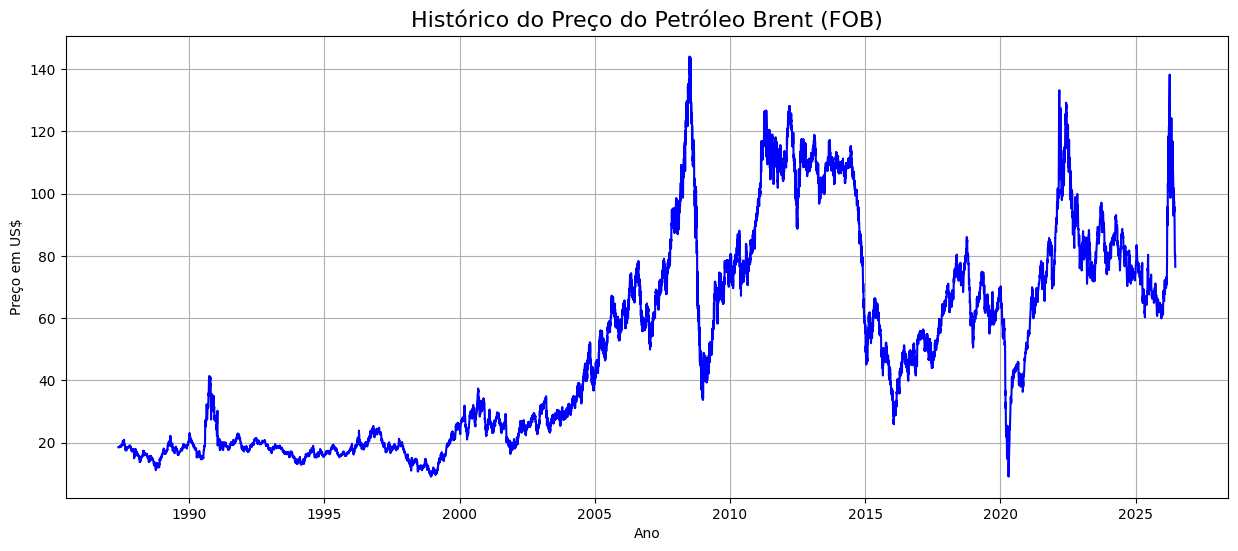

In [7]:
# Gráfico do histórico do preço do petróleo

plt.figure(figsize=(15,6))

plt.plot(df["Data"], df["Preco"], color="blue")

plt.title("Histórico do Preço do Petróleo Brent (FOB)", fontsize=16)

plt.xlabel("Ano")

plt.ylabel("Preço em US$")

plt.grid(True)

plt.show()

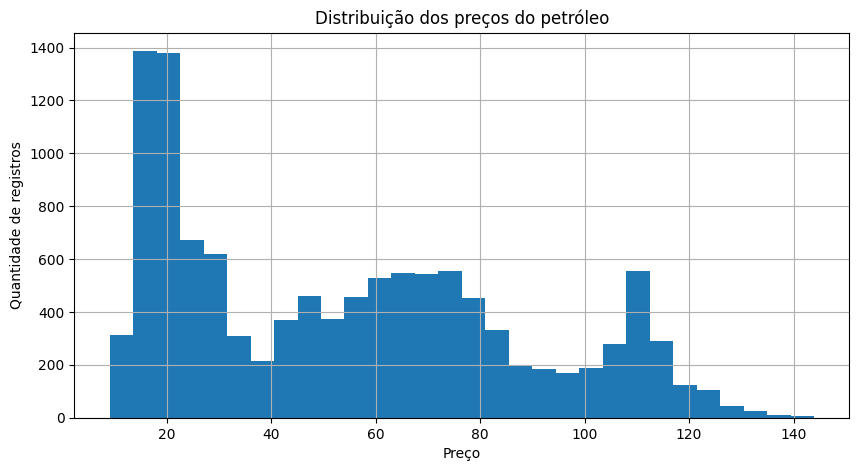

In [8]:
# Distribuição dos preços

plt.figure(figsize=(10,5))

plt.hist(df["Preco"], bins=30)

plt.title("Distribuição dos preços do petróleo")

plt.xlabel("Preço")

plt.ylabel("Quantidade de registros")

plt.grid(True)

plt.show()

In [9]:
# Criando variáveis com os preços dos dias anteriores

df["Lag_1"] = df["Preco"].shift(1)
df["Lag_2"] = df["Preco"].shift(2)
df["Lag_3"] = df["Preco"].shift(3)
df["Lag_4"] = df["Preco"].shift(4)
df["Lag_5"] = df["Preco"].shift(5)

# Removendo linhas vazias criadas pelos lags
df = df.dropna()

# Visualizando o resultado
df.head()

,Data,Preco,Lag_1,Lag_2,Lag_3,Lag_4,Lag_5
5,1987-05-27,18.60,18.63,18.60,18.55,18.45,18.63
6,1987-05-28,18.60,18.60,18.63,18.60,18.55,18.45
7,1987-05-29,18.58,18.60,18.60,18.63,18.60,18.55
8,1987-06-01,18.65,18.58,18.60,18.60,18.63,18.60
9,1987-06-02,18.68,18.65,18.58,18.60,18.60,18.63


In [10]:
# Separando as variáveis de entrada (X) e a variável que queremos prever (y)

X = df[["Lag_1", "Lag_2", "Lag_3", "Lag_4", "Lag_5"]]

y = df["Preco"]

print("Quantidade de registros:", len(X))
print(X.head())

Quantidade de registros: 11696
   Lag_1  Lag_2  Lag_3  Lag_4  Lag_5
5  18.63  18.60  18.55  18.45  18.63
6  18.60  18.63  18.60  18.55  18.45
7  18.60  18.60  18.63  18.60  18.55
8  18.58  18.60  18.60  18.63  18.60
9  18.65  18.58  18.60  18.60  18.63


In [11]:
# Separando dados para treino e teste

divisao = int(len(df) * 0.8)

X_treino = X.iloc[:divisao]
X_teste = X.iloc[divisao:]

y_treino = y.iloc[:divisao]
y_teste = y.iloc[divisao:]

print("Treino:", len(X_treino))
print("Teste:", len(X_teste))

Treino: 9356
Teste: 2340


In [12]:
# Criando o modelo de Machine Learning

modelo = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Treinando o modelo

modelo.fit(X_treino, y_treino)

print("Modelo treinado com sucesso!")

Modelo treinado com sucesso!


In [13]:
# Fazendo previsões

previsoes = modelo.predict(X_teste)

print(previsoes[:10])

[51.54395 52.27395 53.57055 52.72155 54.12085 52.68395 54.2278  54.2819
 54.54465 54.0822 ]


In [14]:
# Avaliando o modelo

mae = mean_absolute_error(y_teste, previsoes)
rmse = np.sqrt(mean_squared_error(y_teste, previsoes))

print("MAE:", round(mae,2))
print("RMSE:", round(rmse,2))

MAE: 1.46
RMSE: 2.17


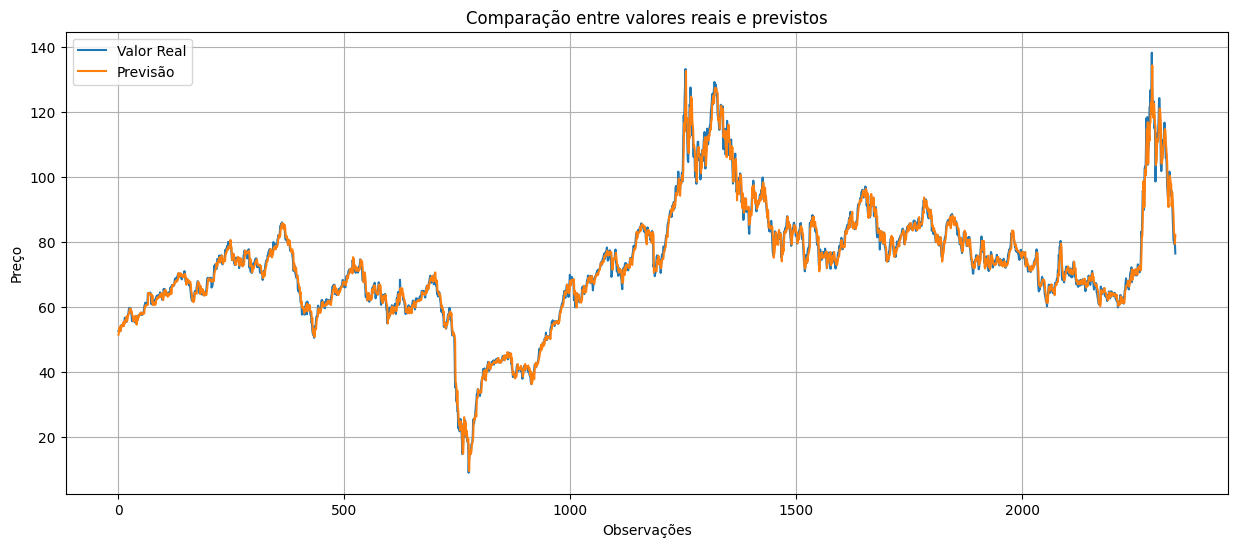

In [15]:
# Comparando valores reais e previstos

plt.figure(figsize=(15,6))

plt.plot(y_teste.values, label="Valor Real")

plt.plot(previsoes, label="Previsão")

plt.title("Comparação entre valores reais e previstos")

plt.xlabel("Observações")

plt.ylabel("Preço")

plt.legend()

plt.grid(True)

plt.show()

In [16]:
# Salvando o modelo treinado

joblib.dump(modelo, "modelo_petroleo.pkl")

print("Modelo salvo com sucesso!")

Modelo salvo com sucesso!


In [17]:
# Fazendo uma previsão utilizando o último registro da base

ultimo_registro = X.iloc[[-1]]

previsao_futura = modelo.predict(ultimo_registro)

print("Último preço conhecido:", y.iloc[-1])
print("Preço previsto pelo modelo:", round(previsao_futura[0],2))

Último preço conhecido: 76.49
Preço previsto pelo modelo: 82.14


# Conclusão

Neste projeto foi desenvolvido um modelo preditivo utilizando o algoritmo Random Forest Regressor para estimar o preço do petróleo Brent (FOB).

Inicialmente foi realizada a coleta dos dados históricos disponibilizados pelo IPEA, seguida pela etapa de tratamento e análise exploratória dos dados.

Para melhorar a capacidade preditiva do modelo, foram criadas variáveis de atraso (lags), permitindo que o algoritmo utilizasse os preços dos dias anteriores como informações para prever o preço do dia seguinte.

O modelo apresentou desempenho satisfatório, obtendo baixo erro médio absoluto (MAE) e baixo erro quadrático médio (RMSE), demonstrando boa capacidade de acompanhar o comportamento histórico dos preços.

Por fim, o modelo foi salvo para utilização em uma aplicação desenvolvida em Streamlit, permitindo que usuários realizem previsões de forma simples através de uma interface gráfica.